In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
sns.set(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Kuliah/Skripsi/Report Item Details - 01-01-2025 - 31-10-2025 - All_Outlet - 663438 - 6909ce6a.csv'

In [ ]:
df = pd.read_csv(file_path)
df.head()

,Outlet,Receipt Number,Date,Time,Category,Brand,Items,Variant,SKU,Quantity,...,Net Sales,Gratuity,Tax,Sales Type,Collected By,Served By,Customer,Payment Method,Event Type,Reason of Refund
0,Lexon Beauty,3BOI0D,31-10-2025,20:12:31,Selection,Unbranded,8.99104E+12,Selection Kapas 35 gr,SLC-KPS1-TLS-001,1,...,5800.00,0,0,Member,Anugrah Srileksono,NaN,'+6281392099614,BCA QR,Payment,NaN
1,Lexon Beauty,3BOI0D,31-10-2025,20:12:31,Bio Aqua,Unbranded,6.95715E+12,Bio Aqua Sheet Mask Hydrating Essence Grape,BAQ-HEGP-MSK-010,1,...,3490.00,0,0,Member,Anugrah Srileksono,NaN,'+6281392099614,BCA QR,Payment,NaN
2,Lexon Beauty,3BOI0D,31-10-2025,20:12:31,Tools,Unbranded,Spons Puff Bedak Makeup,NaN,TLS-SPMU-SPN-025,1,...,2000.00,0,0,Member,Anugrah Srileksono,NaN,'+6281392099614,BCA QR,Payment,NaN
3,Lexon Beauty,3BOI0D,31-10-2025,20:12:31,Glad2Glow,Unbranded,8.80964E+12,Glad2Glow Mugwort Salicylic Acid Acne Clear Mi...,GTG-MSAA-MWT-054,1,...,46300.00,0,0,Member,Anugrah Srileksono,NaN,'+6281392099614,BCA QR,Payment,NaN
4,Lexon Beauty,3BOI0C,31-10-2025,19:12:33,Glad2Glow,Unbranded,8.80962E+12,Glad2Glow Centella Allantion Soothing Gel Mois...,GTG-MCAK-MST-008,1,...,41600.00,0,0,Non-Member,Anugrah Srileksono,NaN,NaN,BCA QR,Payment,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11722 entries, 0 to 11721
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Outlet            11722 non-null  object 
 1   Receipt Number    11722 non-null  object 
 2   Date              11722 non-null  object 
 3   Time              11722 non-null  object 
 4   Category          11722 non-null  object 
 5   Brand             11722 non-null  object 
 6   Items             11722 non-null  object 
 7   Variant           8570 non-null   object 
 8   SKU               11720 non-null  object 
 9   Quantity          11722 non-null  int64  
 10  Modifier Applied  0 non-null      float64
 11  Discount Applied  1061 non-null   object 
 12  Gross Sales       11722 non-null  int64  
 13  Discounts         11722 non-null  float64
 14  Refunds           11722 non-null  int64  
 15  Net Sales         11722 non-null  float64
 16  Gratuity          11722 non-null  int64 

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Jumlah Hilang': missing, 'Persentase (%)': missing_percent})
print(missing_report[missing_report['Jumlah Hilang'] > 0])

                  Jumlah Hilang  Persentase (%)
Variant                    3152           26.89
SKU                           2            0.02
Modifier Applied          11722          100.00
Discount Applied          10661           90.95
Served By                  4095           34.93
Customer                   4150           35.40
Reason of Refund          11571           98.71


In [ ]:
stats = df[['Quantity', 'Net Sales']].describe()
print(stats)

       Quantity  Net Sales
count  11722.00   11722.00
mean       1.02   28885.70
std        0.37   31462.52
min       -2.00 -182300.00
25%        1.00    7900.00
50%        1.00   21700.00
75%        1.00   38700.00
max       10.00  346500.00


In [ ]:
# Cek jumlah transaksi negatif (Refund/Batal)
neg_sales = df[df['Net Sales'] <= 0]
print(f"\n[TEMUAN] Jumlah Transaksi dengan Net Sales <= 0 (Refund/Error): {len(neg_sales)} transaksi")


[TEMUAN] Jumlah Transaksi dengan Net Sales <= 0 (Refund/Error): 272 transaksi


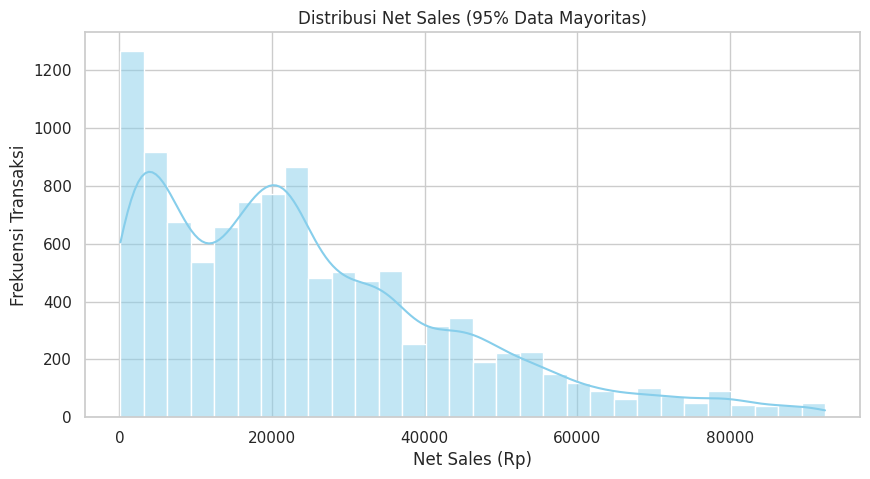

In [ ]:
# --- A. Histogram Distribusi Net Sales ---
plt.figure(figsize=(10, 5))

plot_data = df[(df['Net Sales'] > 0) & (df['Net Sales'] < df['Net Sales'].quantile(0.95))]
sns.histplot(plot_data['Net Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Net Sales (95% Data Mayoritas)')
plt.xlabel('Net Sales (Rp)')
plt.ylabel('Frekuensi Transaksi')
plt.show()

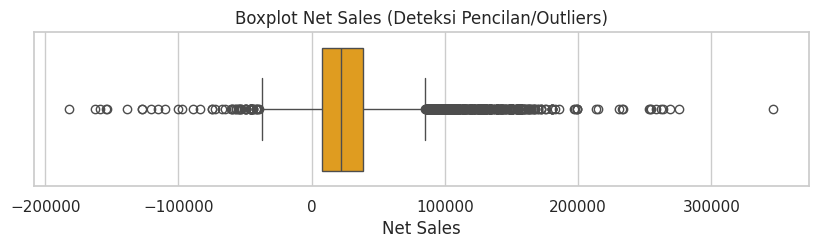

In [ ]:
# --- B. Boxplot (Mendeteksi Outlier) ---
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Net Sales'], color='orange')
plt.title('Boxplot Net Sales (Deteksi Pencilan/Outliers)')
plt.xlabel('Net Sales')
plt.show()

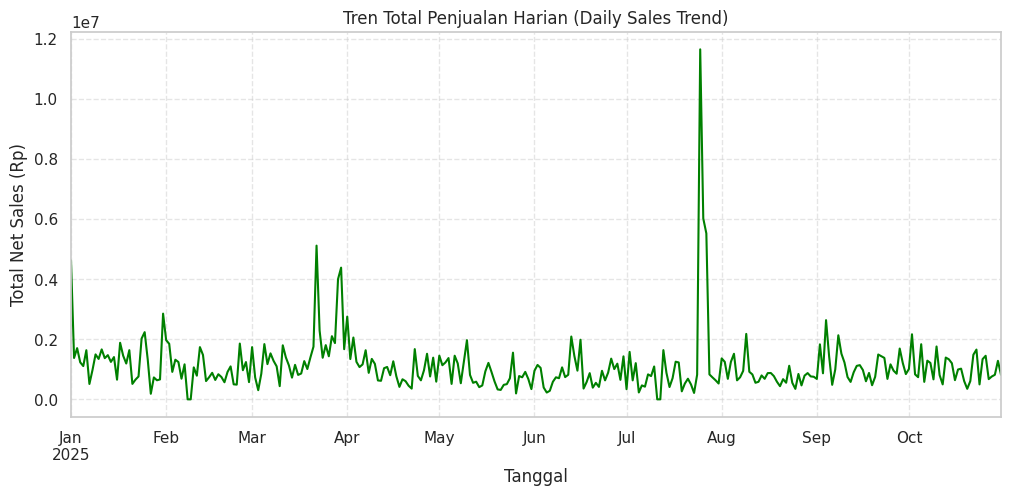

In [ ]:
# Konversi Date dulu untuk plotting
df['Date_Plots'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Agregasi penjualan per hari
daily_sales = df.set_index('Date_Plots').resample('D')['Net Sales'].sum()

plt.figure(figsize=(12, 5))
daily_sales.plot(color='green', linewidth=1.5)
plt.title('Tren Total Penjualan Harian (Daily Sales Trend)')
plt.xlabel('Tanggal')
plt.ylabel('Total Net Sales (Rp)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

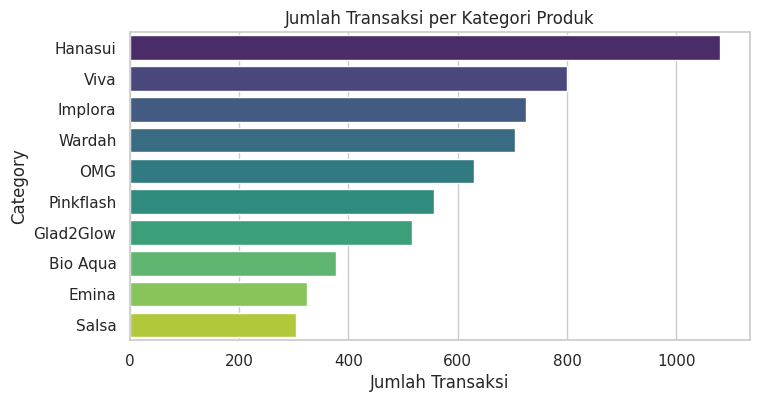

In [ ]:
plt.figure(figsize=(8, 4))

top_cat = df[df['Category'] != 'AA Plastik']['Category'].value_counts().head(10)

# Menambahkan hue agar palette berfungsi dengan benar tanpa warning
sns.barplot(x=top_cat.values, y=top_cat.index, hue=top_cat.index, palette='viridis', legend=False)

plt.title('Jumlah Transaksi per Kategori Produk')
plt.xlabel('Jumlah Transaksi')
plt.show()

In [ ]:
print("\n" + "="*40)
print("HASIL DIAGNOSIS DATA (EDA)")
print("="*40)
print(f"1. Total Baris Data Awal : {len(df)}")
print(f"2. Data Tanpa Customer ID: {df['Customer'].isnull().sum()} ({df['Customer'].isnull().sum()/len(df)*100:.1f}%) -> HARUS DIBUANG utk RFM.")
print(f"3. Transaksi Retur/Minus : {len(df[df['Net Sales'] <= 0])} transaksi -> HARUS DIBUANG.")
print(f"4. Rentang Net Sales     : Rp {df['Net Sales'].min():,.0f} s.d Rp {df['Net Sales'].max():,.0f}")
print("="*40)


HASIL DIAGNOSIS DATA (EDA)
1. Total Baris Data Awal : 11722
2. Data Tanpa Customer ID: 4150 (35.4%) -> HARUS DIBUANG utk RFM.
3. Transaksi Retur/Minus : 272 transaksi -> HARUS DIBUANG.
4. Rentang Net Sales     : Rp -182,300 s.d Rp 346,500


In [ ]:
# TAHAP 2: CLEANING & RFM CALCULATION

print("--- MEMULAI PROSES CLEANING ---")

df_clean = df.dropna(subset=['Customer']).copy()
print(f"1. Sisa baris setelah hapus Customer kosong: {len(df_clean)}")

df_clean = df_clean[df_clean['Net Sales'] > 0]
print(f"2. Sisa baris setelah hapus nilai negatif: {len(df_clean)}")

df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='mixed', dayfirst=True)
print(f"3. Sisa baris setelah konversi ke Datetime: {len(df_clean)}")

print("--- CLEANING SELESAI ---")

--- MEMULAI PROSES CLEANING ---
1. Sisa baris setelah hapus Customer kosong: 7572
2. Sisa baris setelah hapus nilai negatif: 7439
3. Sisa baris setelah konversi ke Datetime: 7439
--- CLEANING SELESAI ---


In [ ]:
# TAHAP 3: HITUNG RFM

latest_date = df_clean['Date'].max() + timedelta(days=1)
print(f"Tanggal Referensi Analisis: {latest_date}")

# Agregasi data per Customer
rfm = df_clean.groupby('Customer').agg({
    'Date': lambda x: (latest_date - x.max()).days,  # Recency: Hari sejak terakhir belanja
    'Receipt Number': 'nunique',                     # Frequency: Jumlah transaksi unik
    'Net Sales': 'sum'                               # Monetary: Total penjualan
}).reset_index()

# Rename Kolom untuk konsistensi dan kejelasan
rfm.rename(columns={
    'Date': 'Recency',
    'Receipt Number': 'Frequency',
    'Net Sales': 'Monetary'
}, inplace=True)

# Lihat hasil sampel RFM
print("\n--- Sampel Data RFM (5 Teratas) ---")
print(rfm.head())
print(f"Total Pelanggan Unik: {len(rfm)}")

Tanggal Referensi Analisis: 2025-11-01 00:00:00

--- Sampel Data RFM (5 Teratas) ---
         Customer  Recency  Frequency  Monetary
0  '+628111038056       72          2 252600.00
1  '+628111220288      190          1 124875.00
2  '+628112199413       55          2 119000.00
3   '+62811251842      217          2 337500.00
4  '+628112578880      188          1 182300.00
Total Pelanggan Unik: 1167


In [ ]:
# NORMALISASI DATA RFM (Z-SCORE)

rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log['Monetary'] = np.log(rfm_log['Monetary'] + 1)
rfm_log['Frequency'] = np.log(rfm_log['Frequency'] + 1)

scaler = StandardScaler()

# Normalisasi pada data Recency, Frequency, dan Monetary
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# Menampilkan data yang sudah ternormalisasi
print("\n--- Data Ternormalisasi (Z-Score) ---")
print(rfm_scaled_df.head())


--- Data Ternormalisasi (Z-Score) ---
   Recency  Frequency  Monetary
0    -0.78       0.24      0.62
1     0.45      -0.66     -0.16
2    -0.96       0.24     -0.22
3     0.73       0.24      0.94
4     0.43      -0.66      0.26



Sedang menghitung Elbow Method...


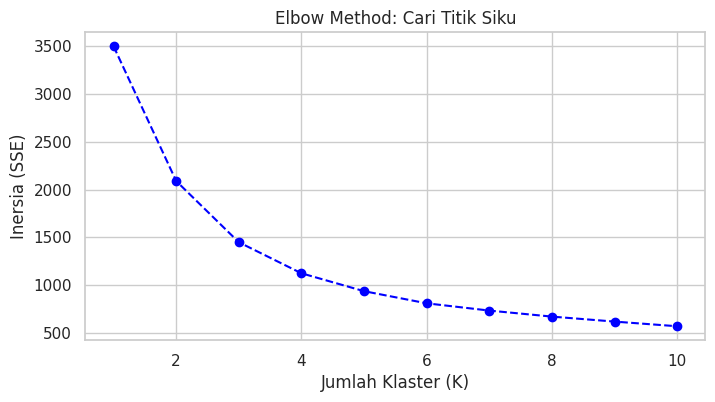

In [ ]:
# TAHAP 5: ELBOW METHOD

sse = []
k_range = range(1, 11)

print("\nSedang menghitung Elbow Method...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    sse.append(kmeans.inertia_)

# Plotting Elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method: Cari Titik Siku')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inersia (SSE)')
plt.grid(True)
plt.show()

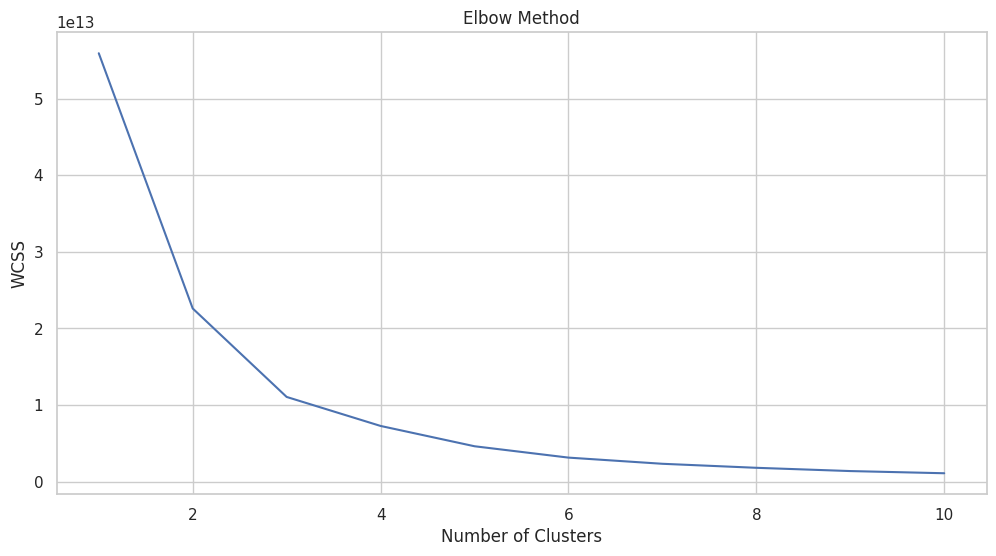

Centroid stabil pada iterasi ke: 14


In [ ]:
# Menentukan range untuk K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(rfm[['Recency', 'Frequency', 'Monetary']])
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

print(f"Centroid stabil pada iterasi ke: {kmeans.n_iter_}")

--- Perhitungan Skor Siluet ---
Klaster (K=2): Silhouette Score = 0.3793
Klaster (K=3): Silhouette Score = 0.3594
Klaster (K=4): Silhouette Score = 0.3578
Klaster (K=5): Silhouette Score = 0.3465
Klaster (K=6): Silhouette Score = 0.3520
Klaster (K=7): Silhouette Score = 0.3406
Klaster (K=8): Silhouette Score = 0.3313
Klaster (K=9): Silhouette Score = 0.2944
Klaster (K=10): Silhouette Score = 0.2987


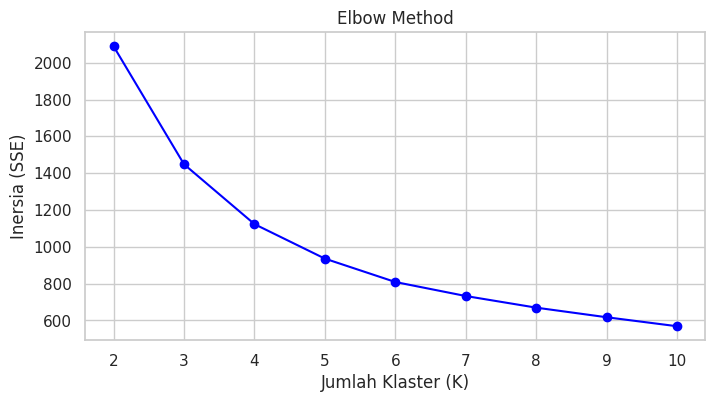

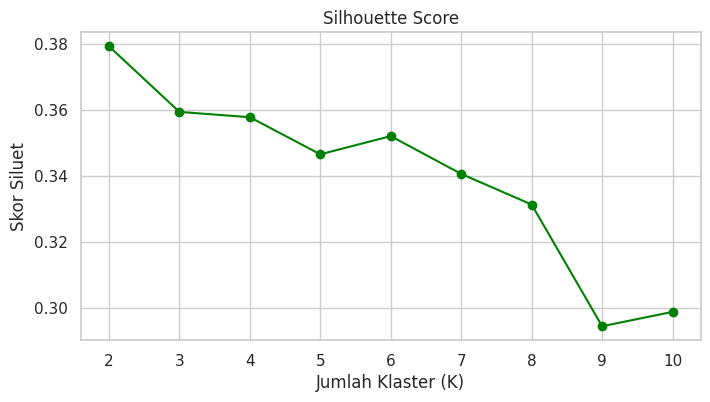

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Gunakan data yang sudah di-scale
data_for_clustering = rfm_scaled_df[['Recency', 'Frequency', 'Monetary']]

sse = []
silhouette_scores = []
k_range = range(2, 11)

print("--- Perhitungan Skor Siluet ---")
for k in k_range:

    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(data_for_clustering)
    sse.append(kmeans.inertia_)

    score = silhouette_score(data_for_clustering, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Klaster (K={k}): Silhouette Score = {score:.4f}")

# Visualisasi Elbow (Tetap gunakan data scaled)
plt.figure(figsize=(8, 4))
plt.plot(k_range, sse, marker='o', color='blue')
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inersia (SSE)')
plt.show()

# Visualisasi Silhouette (Validasi yang kuat)
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Skor Siluet')
plt.show()


--- RINGKASAN PROFIL 3 KLASTER ---
  Cluster Recency Frequency   Monetary                        Customer
             mean      mean       mean       min          max    count
0       0   66.17      5.48 505,943.90 46,100.00 2,259,500.00      208
1       1  237.38      1.22 127,107.79  1,000.00 1,009,300.00      528
2       2   75.58      1.46 171,415.23  5,500.00   661,000.00      431


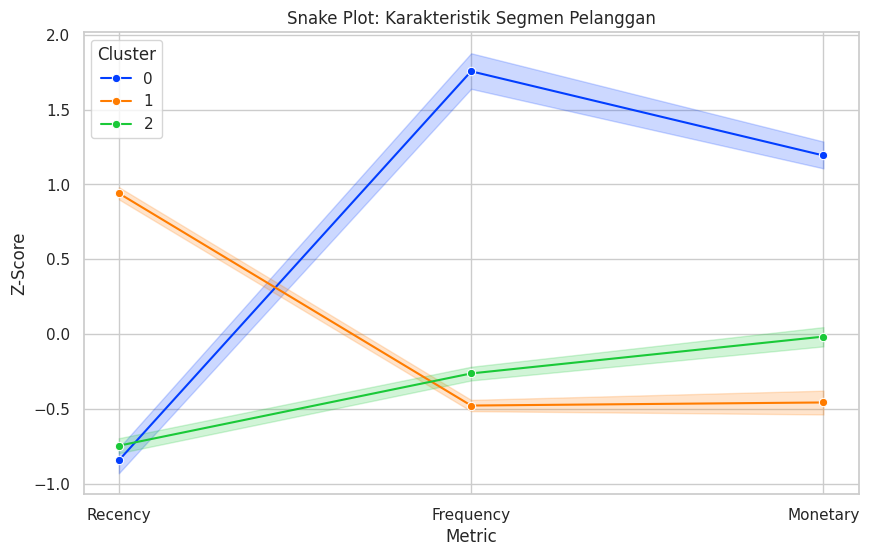

In [ ]:
# TAHAP 6: FINAL CLUSTERING (Eksekusi K-Means)

k_final = 3

kmeans_model = KMeans(n_clusters=k_final, random_state=42, n_init=10)
kmeans_model.fit(rfm_scaled_df)

rfm['Cluster'] = kmeans_model.labels_

# --- Profiling Hasil (Statistik Rata-rata) ---
summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'min', 'max'],
    'Customer': 'count'
}).reset_index()

# Format tampilan agar mudah dibaca (angka desimal dibulatkan)
pd.options.display.float_format = '{:,.2f}'.format
print(f"\n--- RINGKASAN PROFIL {k_final} KLASTER ---")
print(summary)

# --- Visualisasi Snake Plot ---
rfm_scaled_df['Cluster'] = kmeans_model.labels_
rfm_melted = pd.melt(rfm_scaled_df.reset_index(),
                     id_vars=['Cluster'],
                     value_vars=['Recency', 'Frequency', 'Monetary'],
                     var_name='Metric',
                     value_name='Z-Score')

plt.figure(figsize=(10, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Z-Score', hue='Cluster', palette='bright', marker='o')
plt.title('Snake Plot: Karakteristik Segmen Pelanggan')
plt.show()

In [ ]:
# 4. AUTO-LABELING (PEMBERIAN NAMA OTOMATIS)

print("\n--- 4. INTERPRETASI & PEMBERIAN NAMA SEGMEN ---")

# Hitung rata-rata per cluster untuk melihat karakteristiknya
summary_clusters = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer': 'count'
}).reset_index()

summary_sorted = summary_clusters.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

print("Statistik Klaster (Diurutkan dari Monetary Tertinggi):")
print(summary_sorted)


mapping_names = {}

# Ambil Cluster ID asli dari tabel yang sudah diurutkan
best_cluster_id = summary_sorted.iloc[0]['Cluster']   # Rank 1
mid_cluster_id = summary_sorted.iloc[1]['Cluster']    # Rank 2
worst_cluster_id = summary_sorted.iloc[2]['Cluster']  # Rank 3

mapping_names[best_cluster_id] = 'Pelanggan Setia (Loyal/Champion)'
mapping_names[mid_cluster_id] = 'Pelanggan Potensial (Promising)'
mapping_names[worst_cluster_id] = 'Pelanggan Berisiko (At Risk/Lost)'

# Terapkan Nama ke DataFrame Utama
rfm['Nama_Segmen'] = rfm['Cluster'].map(mapping_names)

print("\n--- CONTOH HASIL AKHIR ---")
print(rfm[['Customer', 'Recency', 'Frequency', 'Monetary', 'Nama_Segmen']].head(10))


--- 4. INTERPRETASI & PEMBERIAN NAMA SEGMEN ---
Statistik Klaster (Diurutkan dari Monetary Tertinggi):
   Cluster  Recency  Frequency   Monetary  Customer
0        0    66.17       5.48 505,943.90       208
1        2    75.58       1.46 171,415.23       431
2        1   237.38       1.22 127,107.79       528

--- CONTOH HASIL AKHIR ---
         Customer  Recency  Frequency   Monetary  \
0  '+628111038056       72          2 252,600.00   
1  '+628111220288      190          1 124,875.00   
2  '+628112199413       55          2 119,000.00   
3   '+62811251842      217          2 337,500.00   
4  '+628112578880      188          1 182,300.00   
5  '+628112642011       30          6 980,350.00   
6  '+628112652557      201          2 464,670.00   
7  '+628112663355      289          1  49,900.00   
8   '+62811267690      145          2 235,800.00   
9  '+628112950303       30          1 187,000.00   

                         Nama_Segmen  
0    Pelanggan Potensial (Promising)  
1  Pelang


--- 5. VISUALISASI ---


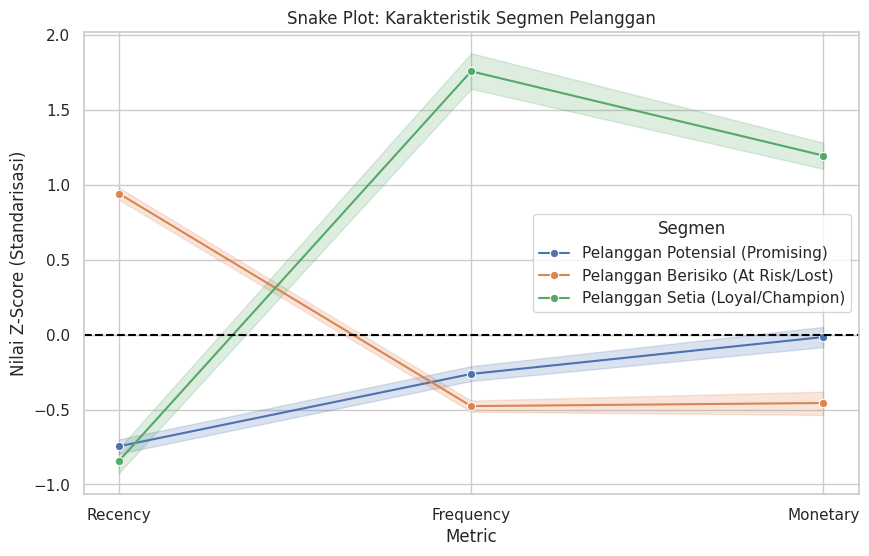

In [ ]:
# 5. VISUALISASI (SNAKE PLOT)

print("\n--- 5. VISUALISASI ---")
# Persiapan Data Plot
rfm_scaled_df['Nama_Segmen'] = rfm['Nama_Segmen']
rfm_melted = pd.melt(rfm_scaled_df, id_vars=['Nama_Segmen'],
                     value_vars=['Recency', 'Frequency', 'Monetary'],
                     var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Value', hue='Nama_Segmen', marker='o')
plt.title('Snake Plot: Karakteristik Segmen Pelanggan')
plt.ylabel('Nilai Z-Score (Standarisasi)')
plt.axhline(0, color='black', linestyle='--')
plt.legend(title='Segmen')
plt.show()

In [ ]:
# 6. EXPORT LAPORAN

print("\n--- 6. MENYIMPAN HASIL ---")

# A. Laporan Level Customer (Ringkasan)
rfm_export = rfm[['Customer', 'Nama_Segmen', 'Recency', 'Frequency', 'Monetary']]
rfm_export.to_excel('Laporan_Status_Pelanggan.xlsx', index=False)
print("[OK] File 'Laporan_Status_Pelanggan.xlsx' berhasil disimpan.")

# B. Laporan Level Transaksi (Detail dengan Label)
# Menggabungkan label segmen kembali ke data transaksi asli
df_detail = df_clean.merge(rfm[['Customer', 'Nama_Segmen']], on='Customer', how='left')

cols_final = ['Date', 'Receipt Number', 'Customer', 'Category', 'Items', 'Quantity', 'Net Sales', 'Nama_Segmen']
df_detail_final = df_detail[cols_final].sort_values(by=['Nama_Segmen', 'Date'], ascending=[True, False])

df_detail_final.to_excel('Data_Transaksi_Berlabel.xlsx', index=False)
print("[OK] File 'Data_Transaksi_Berlabel.xlsx' berhasil disimpan.")

print("\nSELESAI. Silakan unduh file Excel di folder Files.")


--- 6. MENYIMPAN HASIL ---
[OK] File 'Laporan_Status_Pelanggan.xlsx' berhasil disimpan.
[OK] File 'Data_Transaksi_Berlabel.xlsx' berhasil disimpan.

SELESAI. Silakan unduh file Excel di folder Files.


In [ ]:
df_detail_final.head()

,Date,Receipt Number,Customer,Category,Items,Quantity,Net Sales,Nama_Segmen
2302,2025-07-27,3BOH11,'+6287839020055,Bio Aqua,6.95715E+12,1,"1,000.00",Pelanggan Berisiko (At Risk/Lost)
2363,2025-07-26,3BOGZ9,'+6289529414745,Hanasui,8.99882E+12,1,500.00,Pelanggan Berisiko (At Risk/Lost)
2364,2025-07-26,3BOGZ9,'+6289529414745,Hanasui,8.99882E+12,3,"6,000.00",Pelanggan Berisiko (At Risk/Lost)
2850,2025-07-10,3BOGR5,margarethamarkus@gmail.com,Vaseline,9E+12,1,"19,900.00",Pelanggan Berisiko (At Risk/Lost)
2953,2025-07-01,3BOGOB,'+6285279723416,OMG,8.99724E+12,1,"20,200.00",Pelanggan Berisiko (At Risk/Lost)



--- 7. DISTRIBUSI & REKOMENDASI BISNIS ---


/tmp/ipython-input-499/621764471.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=rfm, x='Nama_Segmen', palette='Set2', order=rfm['Nama_Segmen'].value_counts().index)


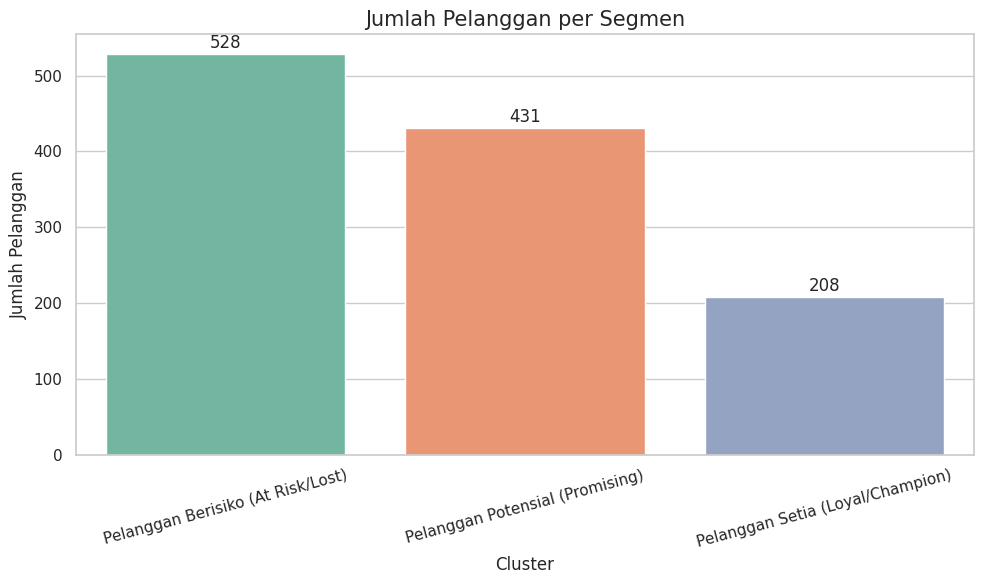


=== TABEL REKOMENDASI STRATEGI BISNIS ===
                              Segmen                    Strategi  \
0    Pelanggan Potensial (Promising)  UP-SELLING & CROSS-SELLING   
1  Pelanggan Berisiko (At Risk/Lost)           WIN-BACK CAMPAIGN   
2   Pelanggan Setia (Loyal/Champion)     RETENTION & EXCLUSIVITY   

                                                                                                                                                                                                                     Langkah  
0       1. Tawarkan paket bundling (Beli 2 gratis 1) untuk menaikkan nilai belanja.\n2. Berikan rekomendasi produk pelengkap (Cross-sell).\n3. Berikan insentif ambang batas (Misal: Belanja 50rb lagi dapat gratis ongkir).  
1                 1. Kirim pesan personal: 'Kami merindukan Anda'.\n2. Berikan diskon besar/voucher waktu terbatas (Urgency) untuk memancing kedatangan kembali.\n3. Lakukan survei kepuasan: Cari tahu kenapa mereka pergi.  
2  1. Berikan p

In [ ]:
# 7. ANALISIS JUMLAH & STRATEGI BISNIS

print("\n--- 7. DISTRIBUSI & REKOMENDASI BISNIS ---")

# A. Visualisasi Jumlah Pelanggan per Segmen
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=rfm, x='Nama_Segmen', palette='Set2', order=rfm['Nama_Segmen'].value_counts().index)
plt.title('Jumlah Pelanggan per Segmen', fontsize=15)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=12)
plt.tight_layout()  # Menyesuaikan layout agar tidak terpotong
plt.show()

# B. Membuat Tabel Rekomendasi Bisnis Otomatis
def berikan_rekomendasi(nama_segmen):
    if 'Loyal' in nama_segmen:
        return [
            ("RETENTION & EXCLUSIVITY", [
                "1. Berikan program loyalitas VIP (Poin/Reward).",
                "2. Akses awal (Early Access) untuk produk baru.",
                "3. Jangan berikan diskon harga berlebih (karena mereka sudah loyal), tetapi berikan 'Experience' atau hadiah eksklusif."
            ])
        ]
    elif 'Potensial' in nama_segmen:
        return [
            ("UP-SELLING & CROSS-SELLING", [
                "1. Tawarkan paket bundling (Beli 2 gratis 1) untuk menaikkan nilai belanja.",
                "2. Berikan rekomendasi produk pelengkap (Cross-sell).",
                "3. Berikan insentif ambang batas (Misal: Belanja 50rb lagi dapat gratis ongkir)."
            ])
        ]
    elif 'Berisiko' in nama_segmen or 'Lost' in nama_segmen:
        return [
            ("WIN-BACK CAMPAIGN", [
                "1. Kirim pesan personal: 'Kami merindukan Anda'.",
                "2. Berikan diskon besar/voucher waktu terbatas (Urgency) untuk memancing kedatangan kembali.",
                "3. Lakukan survei kepuasan: Cari tahu kenapa mereka pergi."
            ])
        ]
    else:
        return [("Analisis lebih lanjut diperlukan.", [])]

# Buat DataFrame Ringkasan untuk Rekomendasi Bisnis
rekomendasi_list = []

# Mengambil nama segmen dari kolom 'Nama_Segmen' pada DataFrame rfm
for segmen in rfm['Nama_Segmen'].unique():
    rekomendasi = berikan_rekomendasi(segmen)
    for rekomendasi_strategi, langkah in rekomendasi:
        rekomendasi_list.append([segmen, rekomendasi_strategi, '\n'.join(langkah)])

# Membuat DataFrame dari rekomendasi_list
df_rekomendasi = pd.DataFrame(rekomendasi_list, columns=['Segmen', 'Strategi', 'Langkah'])

# Tampilkan DataFrame Rekomendasi
print("\n=== TABEL REKOMENDASI STRATEGI BISNIS ===")
pd.set_option('display.max_colwidth', None)  # Agar teks rekomendasi tidak terpotong
print(df_rekomendasi)

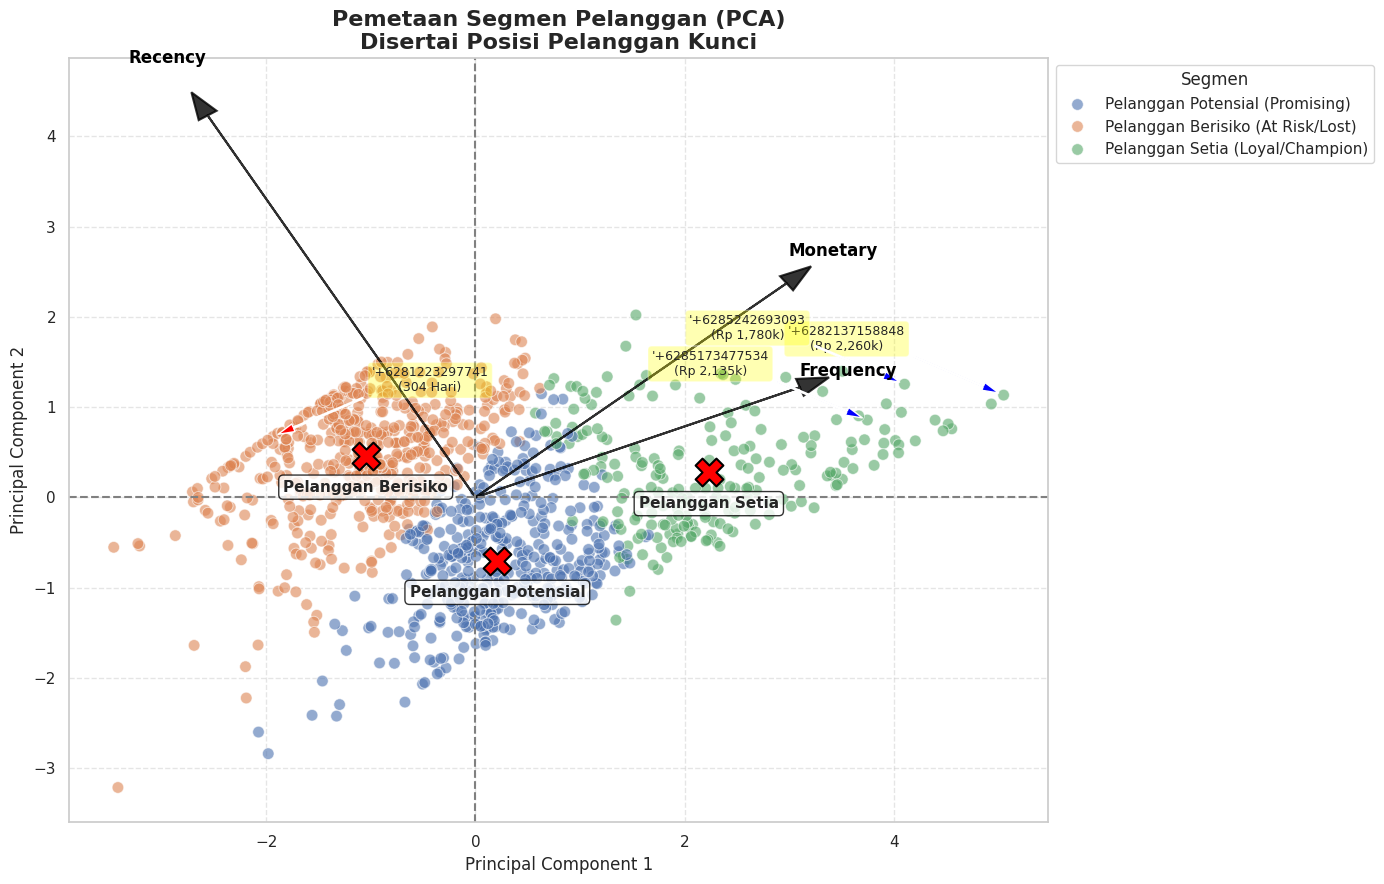

In [ ]:
# VISUALISASI PCA FINAL

pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)

# Masukkan ke DataFrame
rfm_pca = rfm.copy()
rfm_pca['PC1'] = pca_result[:, 0]
rfm_pca['PC2'] = pca_result[:, 1]

# 2. Setup Canvas
plt.figure(figsize=(14, 9))

# A. Scatter Plot Utama
sns.scatterplot(
    data=rfm_pca,
    x='PC1',
    y='PC2',
    hue='Nama_Segmen',
    palette='deep',
    alpha=0.6,
    s=70,
    edgecolor='w'
)

# B. Gambar Centroid & Label Centroid
centroids = rfm_pca.groupby('Nama_Segmen')[['PC1', 'PC2']].mean()

for name, row in centroids.iterrows():
    # Plot Titik Merah Besar (Pusat)
    plt.scatter(row['PC1'], row['PC2'], marker='X', s=400, color='red', edgecolors='black', linewidth=1.5, zorder=5)

    # Label Centroid
    plt.text(
        row['PC1'], row['PC2'] - 0.4,
        name.split('(')[0].strip(),
        horizontalalignment='center',
        fontsize=11,
        fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8, boxstyle='round,pad=0.3'),
        zorder=6
    )

# C. Anotasi Pelanggan Spesifik (HIGHLIGHT) DENGAN ARAH DINAMIS
top_sultans = rfm_pca.nlargest(3, 'Monetary')
most_lost = rfm_pca.nlargest(1, 'Recency')
highlight_points = pd.concat([top_sultans, most_lost])

for i, row in highlight_points.iterrows():
    # 1. Tentukan Isi Teks & Warna
    if row['Customer'] in top_sultans['Customer'].values:
        label_text = f"{row['Customer']}\n(Rp {row['Monetary']/1000:,.0f}k)"
        arrow_col = 'blue'
    else:
        label_text = f"{row['Customer']}\n({row['Recency']} Hari)"
        arrow_col = 'red'

    # 2. LOGIKA ARAH PANAH (Kanan/Kiri)
    # Jika titik ada di kanan (x > 0), teks taruh di kirinya.
    # Jika titik ada di kiri (x < 0), teks taruh di kanannya.
    x_offset = -1.5 if row['PC1'] > 0 else 1.5
    y_offset = 0.5  # Sedikit ke atas biar rapi

    # Gambar Panah Penunjuk
    plt.annotate(
        label_text,
        xy=(row['PC1'], row['PC2']),                     # Titik data asli
        xytext=(row['PC1'] + x_offset, row['PC2'] + y_offset), # Posisi Teks (Dinamis)
        arrowprops=dict(facecolor=arrow_col, shrink=0.05, width=1, headwidth=6),
        fontsize=9,
        horizontalalignment='center', # Biar teks rapi di tengah
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3)
    )

# D. Gambar Vektor Biplot (Arah Variabel)
components = pca.components_.T
variables = ['Recency', 'Frequency', 'Monetary']
scale_arrow = 5

for i, var_name in enumerate(variables):
    plt.arrow(0, 0, components[i, 0]*scale_arrow, components[i, 1]*scale_arrow,
              color='black', alpha=0.8, head_width=0.2, linewidth=1.5)
    plt.text(components[i, 0]*scale_arrow*1.15, components[i, 1]*scale_arrow*1.15,
             var_name, color='black', ha='center', va='center', fontsize=12, fontweight='bold')

# E. Finalisasi (GARIS TENGAH TETAP ADA)
plt.title('Pemetaan Segmen Pelanggan (PCA)\nDisertai Posisi Pelanggan Kunci', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Segmen', bbox_to_anchor=(1, 1), loc='upper left')

# Garis Grid
plt.grid(True, linestyle='--', alpha=0.5)

# GARIS TENGAH (Horizontal & Vertikal) - SESUAI REQUEST
plt.axhline(0, color='grey', linestyle='--', linewidth=1.5) # Garis Horizontal 0
plt.axvline(0, color='grey', linestyle='--', linewidth=1.5) # Garis Vertikal 0

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# VISUALISASI PCA INTERAKTIF (PLOTLY)
# ==========================================
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# 1. Pastikan PCA & Data Siap
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)

# Masukkan ke DataFrame
rfm_pca = rfm.copy()
rfm_pca['PC1'] = pca_result[:, 0]
rfm_pca['PC2'] = pca_result[:, 1]

# Format Angka untuk Tooltip (Supaya Cantik saat di-hover)
rfm_pca['Ket_Monetary'] = rfm_pca['Monetary'].apply(lambda x: f"Rp {x:,.0f}")
rfm_pca['Ket_Recency'] = rfm_pca['Recency'].astype(str) + " Hari"

# 2. BUAT PLOT INTERAKTIF (SCATTER)
fig = px.scatter(
    rfm_pca,
    x='PC1',
    y='PC2',
    color='Nama_Segmen', # Warna berdasarkan segmen
    hover_name='Customer', # JUDUL POPUP (Saat kursor nempel)
    hover_data={
        'PC1': False, 'PC2': False, # Sembunyikan koordinat teknis
        'Nama_Segmen': True,
        'Ket_Monetary': True,       # Tampilkan Uang
        'Ket_Recency': True,        # Tampilkan Hari
        'Frequency': True           # Tampilkan Frekuensi
    },
    title='Peta Interaktif Segmen Pelanggan (Arahkan Kursor ke Titik)',
    color_discrete_sequence=px.colors.qualitative.Bold # Warna yang tegas
)

# 3. TAMBAHKAN CENTROID (PUSAT KLASTER)
centroids = rfm_pca.groupby('Nama_Segmen')[['PC1', 'PC2']].mean().reset_index()

fig.add_trace(go.Scatter(
    x=centroids['PC1'],
    y=centroids['PC2'],
    mode='markers+text',
    marker=dict(symbol='x', size=15, color='black', line=dict(width=2)),
    text=centroids['Nama_Segmen'], # Label Nama Segmen Permanen
    textposition="bottom center",
    textfont=dict(size=12, color='black', family="Arial Black"),
    name='Centroid (Pusat)',
    hoverinfo='skip' # Centroid gak perlu popup
))

# 4. TAMBAHKAN VEKTOR BIPLOT (PANAH ARAH VARIABEL)
components = pca.components_.T
variables = ['Recency', 'Frequency', 'Monetary']
scale_arrow = 5 # Atur panjang panah di sini

for i, var_name in enumerate(variables):
    fig.add_annotation(
        x=components[i, 0] * scale_arrow,
        y=components[i, 1] * scale_arrow,
        ax=0, ay=0, # Ekor panah di titik 0,0
        xref='x', yref='y', axref='x', ayref='y',
        text=var_name,
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='red',
        font=dict(size=14, color="red", family="Arial Black")
    )

# 5. PERCANTIK TAMPILAN (LAYOUT)
fig.update_layout(
    plot_bgcolor='white',
    width=1000,
    height=700,
    xaxis=dict(showgrid=True, gridcolor='#e5e5e5', zeroline=True, zerolinecolor='grey'),
    yaxis=dict(showgrid=True, gridcolor='#e5e5e5', zeroline=True, zerolinecolor='grey'),
    legend_title_text='Segmen Pelanggan'
)

# Tampilkan
fig.show()

# Task
Calculate and display the skewness for 'Recency', 'Frequency', and 'Monetary' in the `rfm` and `rfm_scaled_df` DataFrames, and visualize their distributions using histograms for both original and scaled data.

## Check Skewness Before Scaling

### Subtask:
Calculate and display the skewness for 'Recency', 'Frequency', and 'Monetary' columns in the original 'rfm' DataFrame.


**Reasoning**:
To calculate the skewness of the specified columns, I will use the `.skew()` method on the 'Recency', 'Frequency', and 'Monetary' columns of the `rfm` DataFrame and print the result.



In [ ]:
print("Skewness of RFM features (original data):")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew())

Skewness of RFM features (original data):
Recency     0.07
Frequency   3.79
Monetary    3.55
dtype: float64


**Reasoning**:
Now that the skewness for the original `rfm` DataFrame has been calculated, the next step in the main task is to calculate and display the skewness for the 'Recency', 'Frequency', and 'Monetary' columns in the `rfm_scaled_df` DataFrame, which contains the normalized data.



In [ ]:
print("Skewness of RFM features (scaled data):")
print(rfm_scaled_df[['Recency', 'Frequency', 'Monetary']].skew())

Skewness of RFM features (scaled data):
Recency      0.07
Frequency    1.70
Monetary    -0.48
dtype: float64


**Reasoning**:
To visualize the distribution of 'Recency', 'Frequency', and 'Monetary' for both the original (`rfm`) and scaled (`rfm_scaled_df`) data, I will create histograms. This will allow for a direct comparison of the distributions before and after scaling.



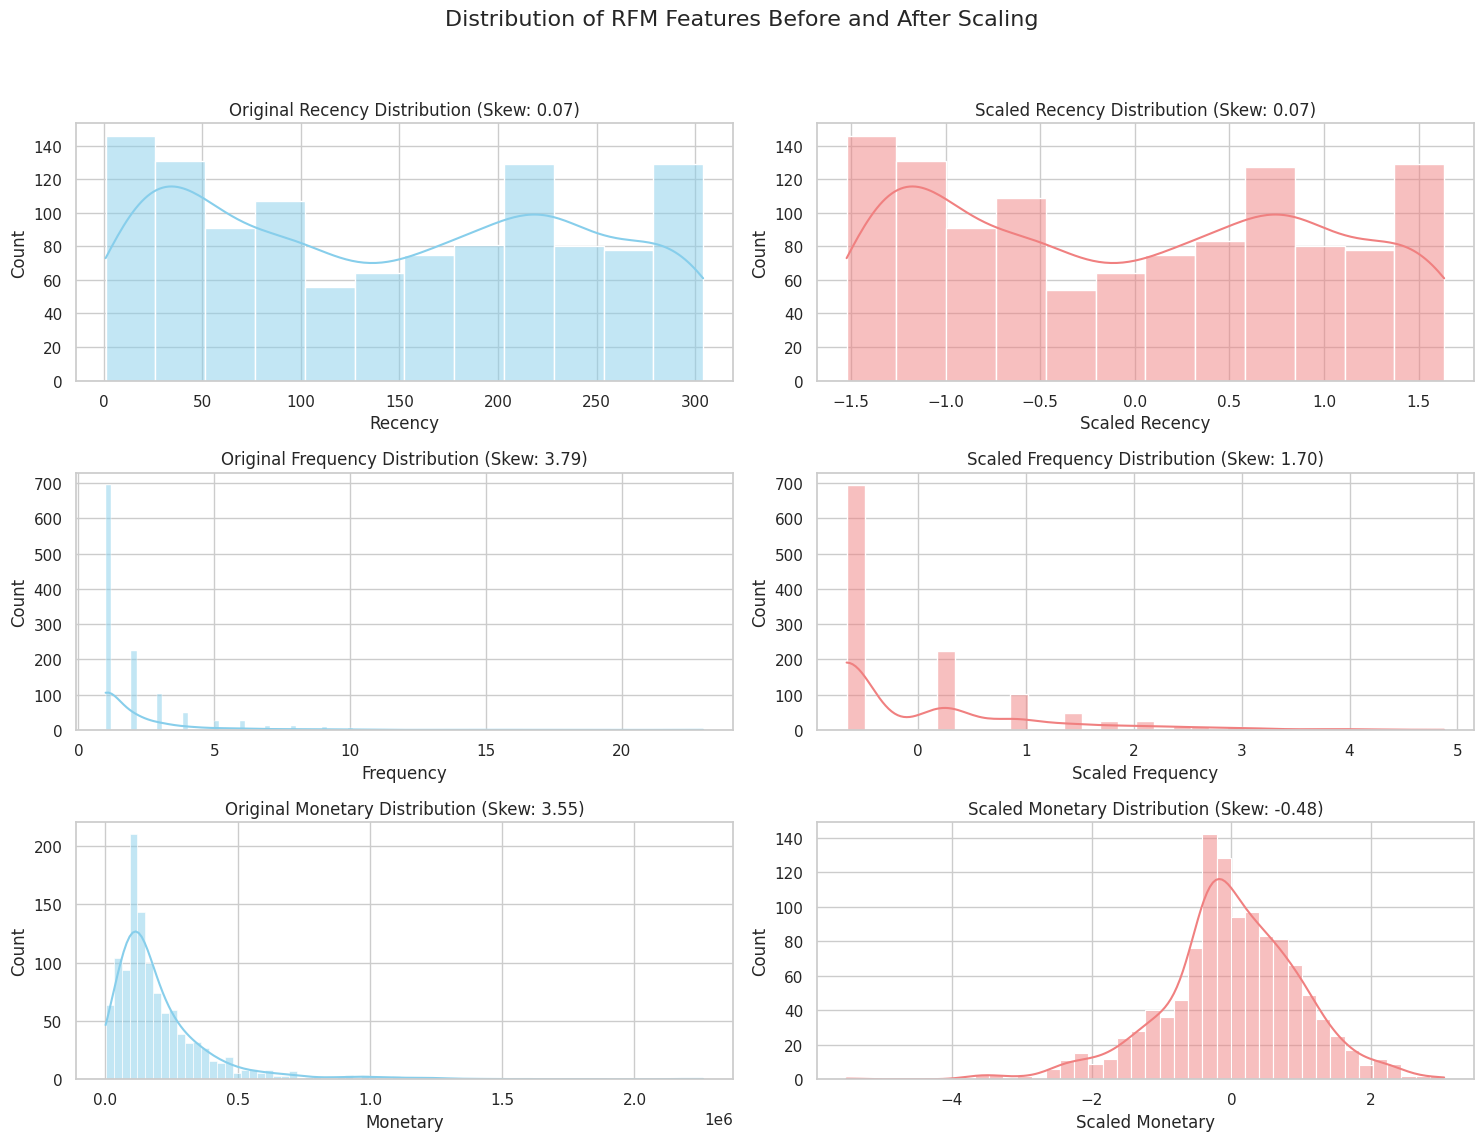

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Distribution of RFM Features Before and After Scaling', fontsize=16)

features = ['Recency', 'Frequency', 'Monetary']

for i, feature in enumerate(features):
    # Histogram for original data
    sns.histplot(rfm[feature], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Original {feature} Distribution (Skew: {rfm[feature].skew():.2f})')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Count')

    # Histogram for scaled data
    sns.histplot(rfm_scaled_df[feature], kde=True, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Scaled {feature} Distribution (Skew: {rfm_scaled_df[feature].skew():.2f})')
    axes[i, 1].set_xlabel(f'Scaled {feature}')
    axes[i, 1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Summary:

### Data Analysis Key Findings
*   The 'Recency' feature in the original `rfm` DataFrame exhibits a nearly symmetrical distribution, with a skewness of approximately 0.07.
*   Both 'Frequency' and 'Monetary' features in the original `rfm` DataFrame show a strong positive skew, with skewness values of approximately 3.79 and 3.55, respectively. This indicates a concentration of lower values and a long tail towards higher values.
*   Histograms were generated to visualize the distributions of 'Recency', 'Frequency', and 'Monetary' for both the original `rfm` and scaled `rfm_scaled_df` DataFrames, allowing for a visual comparison of their distributions before and after scaling.

### Insights or Next Steps
*   The significant positive skewness observed in 'Frequency' and 'Monetary' suggests that these features might require further transformation (e.g., log transformation) to achieve a more normal distribution, which is often beneficial for clustering or regression models.
*   A deeper analysis of the skewness values for the scaled data (`rfm_scaled_df`) would be beneficial to confirm whether the scaling method effectively reduced the skewness in 'Frequency' and 'Monetary' or if further transformations are still needed.


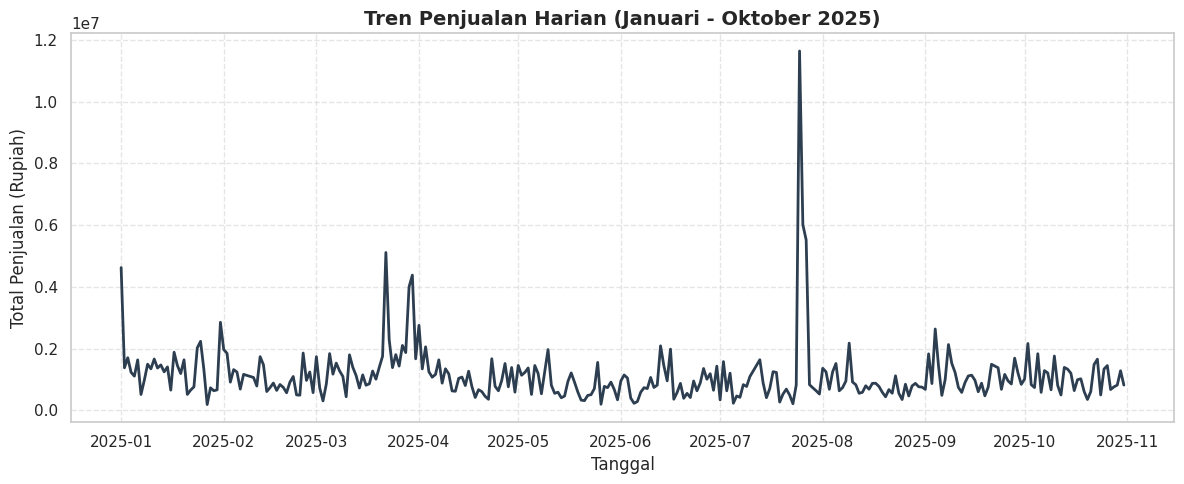

Gambar disimpan sebagai 'Gambar_4_1_Tren_Penjualan.png'


In [ ]:
# ==============================================================================
# OUTPUT GAMBAR 4.1: TREN PENJUALAN HARIAN
# ==============================================================================
# Pastikan kolom Date bertipe datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Agregasi penjualan per hari
daily_sales = df.groupby('Date')['Net Sales'].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, color='#2c3e50', linewidth=2)
plt.title('Tren Penjualan Harian (Januari - Oktober 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan (Rupiah)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Simpan Gambar
plt.savefig('Gambar_4_1_Tren_Penjualan.png', dpi=300)
plt.show()
print("Gambar disimpan sebagai 'Gambar_4_1_Tren_Penjualan.png'")

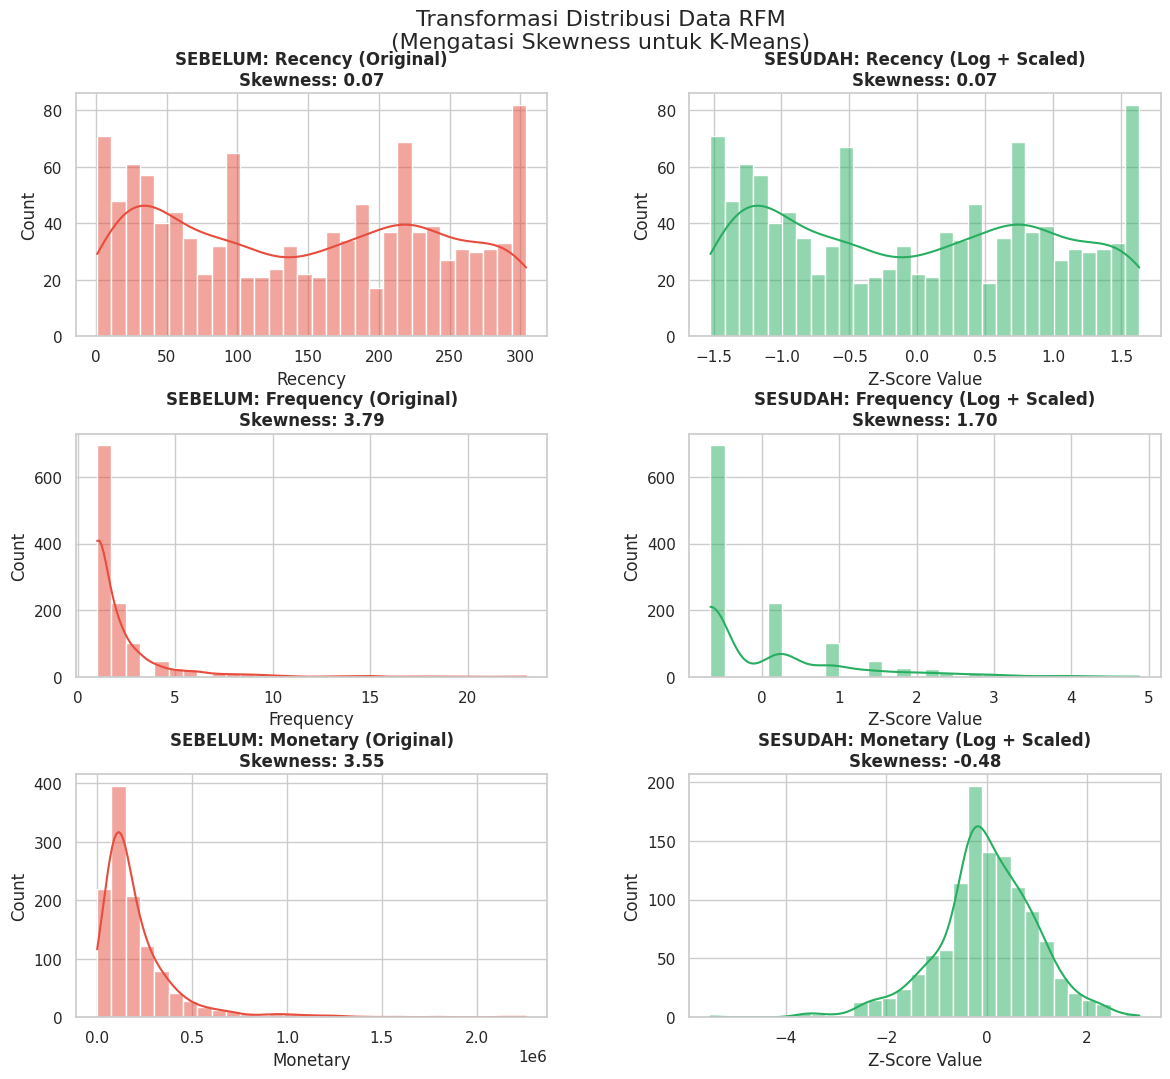

In [ ]:
# OUTPUT GAMBAR 4.2: PERBANDINGAN DISTRIBUSI (BEFORE VS AFTER)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

features = ['Recency', 'Frequency', 'Monetary']
colors_orig = ['#e74c3c', '#e74c3c', '#e74c3c'] # Merah (Masalah)
colors_proc = ['#27ae60', '#27ae60', '#27ae60'] # Hijau (Solusi)

for i, col in enumerate(features):
    # --- PLOT KIRI (DATA ASLI) ---
    sns.histplot(rfm[col], kde=True, ax=axes[i, 0], color=colors_orig[i], bins=30)
    skew_val = rfm[col].skew()
    axes[i, 0].set_title(f'SEBELUM: {col} (Original)\nSkewness: {skew_val:.2f}', fontweight='bold')

    # --- PLOT KANAN (DATA SETELAH DIOLAH) ---
    sns.histplot(rfm_scaled_df[col], kde=True, ax=axes[i, 1], color=colors_proc[i], bins=30)
    skew_val_new = rfm_scaled_df[col].skew()
    axes[i, 1].set_title(f'SESUDAH: {col} (Log + Scaled)\nSkewness: {skew_val_new:.2f}', fontweight='bold')
    axes[i, 1].set_xlabel('Z-Score Value')

plt.suptitle('Transformasi Distribusi Data RFM\n(Mengatasi Skewness untuk K-Means)', fontsize=16, y=0.95)

# Simpan Gambar
plt.savefig('Gambar_4_2_Before_After_Distribution.png', dpi=300)
plt.show()

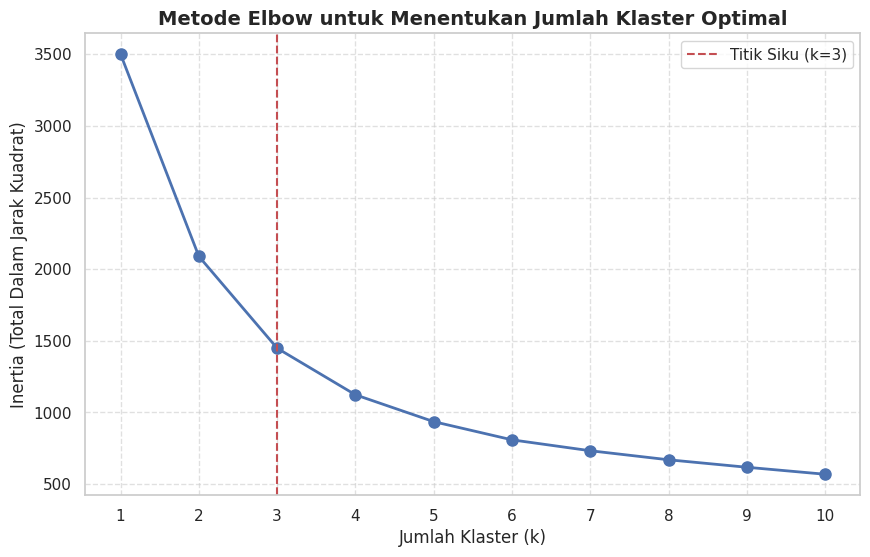

In [ ]:
# ==============================================================================
# OUTPUT GAMBAR 4.3: ELBOW METHOD
# ==============================================================================
inertia = []
range_k = range(1, 11)

for k in range_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fix: Ensure only numerical columns are passed to KMeans
    kmeans_temp.fit(rfm_scaled_df[['Recency', 'Frequency', 'Monetary']])
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_k, inertia, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia (Total Dalam Jarak Kuadrat)')
plt.xticks(range_k)
plt.grid(True, linestyle='--', alpha=0.6)

# Tandai titik siku (Misal K=3)
plt.axvline(x=3, color='r', linestyle='--', label='Titik Siku (k=3)')
plt.legend()

plt.savefig('Gambar_4_3_Elbow_Method.png', dpi=300)
plt.show()

--- TABEL 4.X PROFIL KLASTER (Copy ke Bab 4) ---
   Cluster  Recency  Frequency   Monetary  Count          Nama Segmen
0        0    66.17       5.48 505,943.90    208      Pelanggan Setia
1        1   237.38       1.22 127,107.79    528   Pelanggan Berisiko
2        2    75.58       1.46 171,415.23    431  Pelanggan Potensial


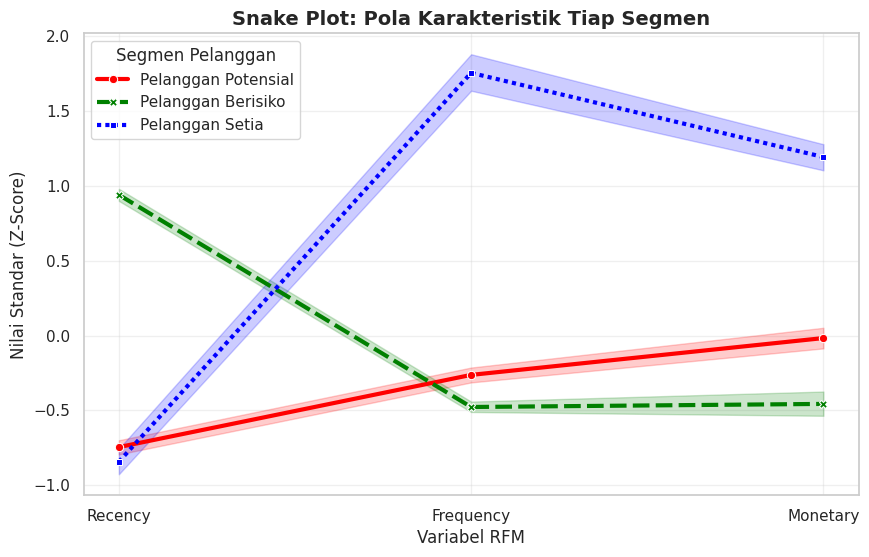

In [ ]:
# ==============================================================================
# PROSES UTAMA: K-MEANS DENGAN K=3
# ==============================================================================
# 1. Fit Model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# FIX: Select only the numerical RFM columns for fitting
kmeans.fit(rfm_scaled_df[['Recency', 'Frequency', 'Monetary']])
rfm['Cluster'] = kmeans.labels_

# 2. Buat Tabel Rata-Rata (Centroid) untuk Laporan
summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
summary['Count'] = rfm.groupby('Cluster')['Customer'].count().values

# Labeling manual (Sesuaikan dengan hasil print summary Anda nanti!)
# Misal: Cluster mana yang uangnya paling banyak -> Loyal
# Di sini saya pakai logika dinamis sederhana untuk contoh
def assign_label(row):
    if row['Monetary'] == summary['Monetary'].max():
        return 'Pelanggan Setia'
    elif row['Recency'] == summary['Recency'].max():
        return 'Pelanggan Berisiko'
    else:
        return 'Pelanggan Potensial'

summary['Nama Segmen'] = summary.apply(assign_label, axis=1)

print("--- TABEL 4.X PROFIL KLASTER (Copy ke Bab 4) ---")
print(summary)

# ==============================================================================
# OUTPUT GAMBAR 4.4: SNAKE PLOT
# ==============================================================================
# Persiapan Data untuk Snake Plot
# Ensure 'Cluster' is added to rfm_scaled_df *after* fitting K-Means, or select columns properly.
# It might be better to re-add it here if rfm_scaled_df was modified elsewhere.
# For now, let's assume rfm_scaled_df still has its original numerical columns, and we're adding cluster labels from rfm
rfm_scaled_df_for_plot = rfm_scaled_df[['Recency', 'Frequency', 'Monetary']].copy() # Create a clean copy
rfm_scaled_df_for_plot['Cluster'] = rfm['Cluster']

rfm_melted = pd.melt(rfm_scaled_df_for_plot.reset_index(),
                     id_vars=['Cluster'],
                     value_vars=['Recency', 'Frequency', 'Monetary'],
                     var_name='Atribut',
                     value_name='Nilai (Standardized)')

# Mapping nama klaster ke angka agar legend-nya bagus
cluster_map = dict(zip(summary['Cluster'], summary['Nama Segmen']))
rfm_melted['Nama Segmen'] = rfm_melted['Cluster'].map(cluster_map)

plt.figure(figsize=(10, 6))
sns.lineplot(x='Atribut', y='Nilai (Standardized)', hue='Nama Segmen', data=rfm_melted,
             palette=['red', 'green', 'blue'], linewidth=3, markers=True, style='Nama Segmen')

plt.title('Snake Plot: Pola Karakteristik Tiap Segmen', fontsize=14, fontweight='bold')
plt.xlabel('Variabel RFM')
plt.ylabel('Nilai Standar (Z-Score)')
plt.legend(title='Segmen Pelanggan')
plt.grid(True, alpha=0.3)

plt.savefig('Gambar_4_4_Snake_Plot.png', dpi=300)
plt.show()

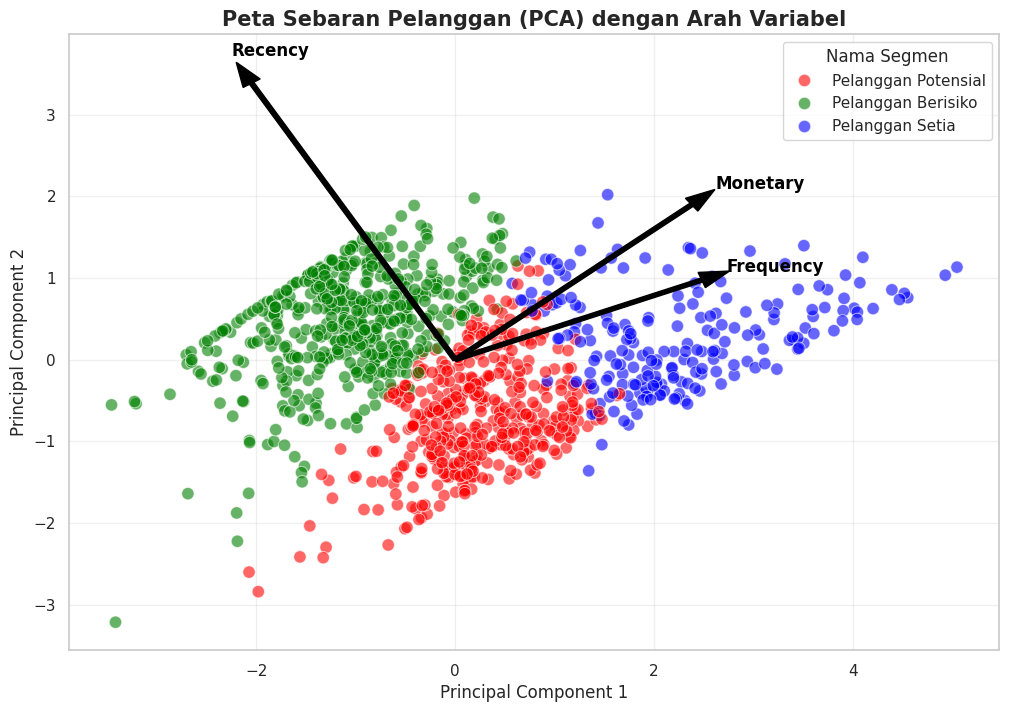

In [ ]:
# ==============================================================================
# OUTPUT GAMBAR 4.5: PCA BIPLOT
# ==============================================================================
from sklearn.decomposition import PCA

# 1. Hitung PCA
pca = PCA(n_components=2)
# Fix: Ensure only numerical RFM columns are passed to PCA
pca_result = pca.fit_transform(rfm_scaled_df[['Recency', 'Frequency', 'Monetary']])
rfm['PC1'] = pca_result[:, 0]
rfm['PC2'] = pca_result[:, 1]
rfm['Nama Segmen'] = rfm['Cluster'].map(cluster_map)

# 2. Plot Scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Nama Segmen', data=rfm, palette=['red', 'green', 'blue'], alpha=0.6, s=80)

# 3. Tambahkan Panah Vektor (Biplot)
components = pca.components_.T
variables = ['Recency', 'Frequency', 'Monetary']
scale_arrow = 4 # Skala panjang panah (sesuaikan jika kependekan/kepanjangan)

for i, var_name in enumerate(variables):
    plt.arrow(0, 0, components[i, 0]*scale_arrow, components[i, 1]*scale_arrow,
              color='black', width=0.05, head_width=0.2)
    plt.text(components[i, 0]*scale_arrow*1.1, components[i, 1]*scale_arrow*1.1,
             var_name, color='black', fontweight='bold', fontsize=12)

plt.title('Peta Sebaran Pelanggan (PCA) dengan Arah Variabel', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)

plt.savefig('Gambar_4_5_PCA_Biplot.png', dpi=300)
plt.show()

/tmp/ipython-input-499/3719091021.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




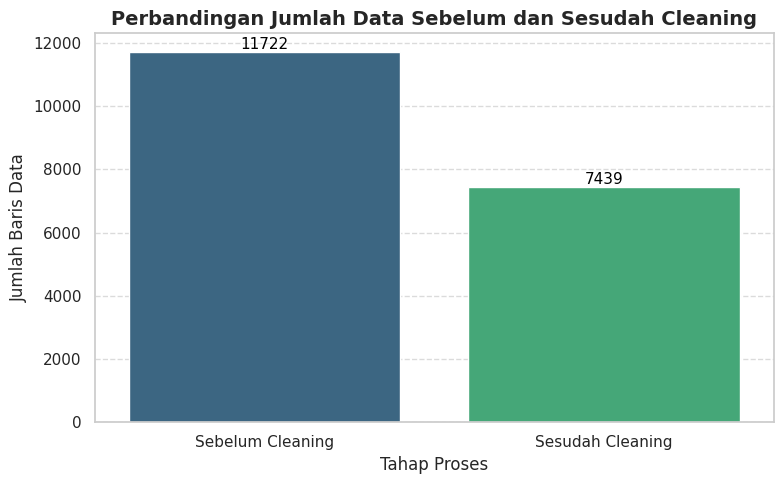

In [ ]:
# Get data counts before and after cleaning
initial_data_count = len(df)
cleaned_data_count = len(df_clean)

# Create a DataFrame for plotting
comparison_data = pd.DataFrame({
    'Stage': ['Sebelum Cleaning', 'Sesudah Cleaning'],
    'Jumlah Data': [initial_data_count, cleaned_data_count]
})

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Stage', y='Jumlah Data', data=comparison_data, palette='viridis')
plt.title('Perbandingan Jumlah Data Sebelum dan Sesudah Cleaning', fontsize=14, fontweight='bold')
plt.xlabel('Tahap Proses', fontsize=12)
plt.ylabel('Jumlah Baris Data', fontsize=12)

# Add data labels on top of the bars
for index, row in comparison_data.iterrows():
    plt.text(index, row['Jumlah Data'], f'{row['Jumlah Data']}', color='black', ha="center", va='bottom', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Tampilan dan Tipe Data 'Date' sebelum konversi (dari DataFrame asli 'df')
print("Sebelum Konversi (DataFrame 'df'):")
print(f"Tipe data kolom 'Date': {df['Date'].dtype}")
print("Contoh data kolom 'Date':")
print(df['Date'].head())

print("\n" + "="*50 + "\n")

# Tampilan dan Tipe Data 'Date' setelah konversi (dari DataFrame bersih 'df_clean')
# Perlu diingat bahwa di cell sebelumnya, df_clean['Date'] sudah dikonversi ke datetime
print("Setelah Konversi (DataFrame 'df_clean'):")
print(f"Tipe data kolom 'Date': {df_clean['Date'].dtype}")
print("Contoh data kolom 'Date':")
print(df_clean['Date'].head())

Sebelum Konversi (DataFrame 'df'):
Tipe data kolom 'Date': datetime64[ns]
Contoh data kolom 'Date':
0   2025-10-31
1   2025-10-31
2   2025-10-31
3   2025-10-31
4   2025-10-31
Name: Date, dtype: datetime64[ns]


Setelah Konversi (DataFrame 'df_clean'):
Tipe data kolom 'Date': datetime64[ns]
Contoh data kolom 'Date':
0    2025-10-31
1    2025-10-31
2    2025-10-31
3    2025-10-31
12   2025-10-31
Name: Date, dtype: datetime64[ns]


In [ ]:
import pandas as pd

# Muat ulang data ke DataFrame sementara untuk demonstrasi
df_temp = pd.read_csv(file_path)

print("--- Data 'Date' dalam format ASLI (object) ---")
print(f"Tipe data kolom 'Date' (df_temp): {df_temp['Date'].dtype}")
print("Contoh data kolom 'Date' sebelum konversi:")
# Tampilkan beberapa contoh yang mungkin punya format berbeda
print(df_temp['Date'].head(10))

print("\n" + "="*50 + "\n")

# Konversi kolom 'Date' ke datetime dengan format='mixed', dayfirst=True
df_temp['Date_Converted'] = pd.to_datetime(df_temp['Date'], format='mixed', dayfirst=True)

print("--- Data 'Date' setelah KONVERSI (datetime) ---")
print(f"Tipe data kolom 'Date_Converted' (df_temp): {df_temp['Date_Converted'].dtype}")
print("Contoh data kolom 'Date' setelah konversi:")
print(df_temp['Date_Converted'].head(10))

--- Data 'Date' dalam format ASLI (object) ---
Tipe data kolom 'Date' (df_temp): object
Contoh data kolom 'Date' sebelum konversi:
0    31-10-2025
1    31-10-2025
2    31-10-2025
3    31-10-2025
4    31-10-2025
5    31-10-2025
6    31-10-2025
7    31-10-2025
8    31-10-2025
9    31-10-2025
Name: Date, dtype: object


--- Data 'Date' setelah KONVERSI (datetime) ---
Tipe data kolom 'Date_Converted' (df_temp): datetime64[ns]
Contoh data kolom 'Date' setelah konversi:
0   2025-10-31
1   2025-10-31
2   2025-10-31
3   2025-10-31
4   2025-10-31
5   2025-10-31
6   2025-10-31
7   2025-10-31
8   2025-10-31
9   2025-10-31
Name: Date_Converted, dtype: datetime64[ns]


/tmp/ipython-input-499/4066120473.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




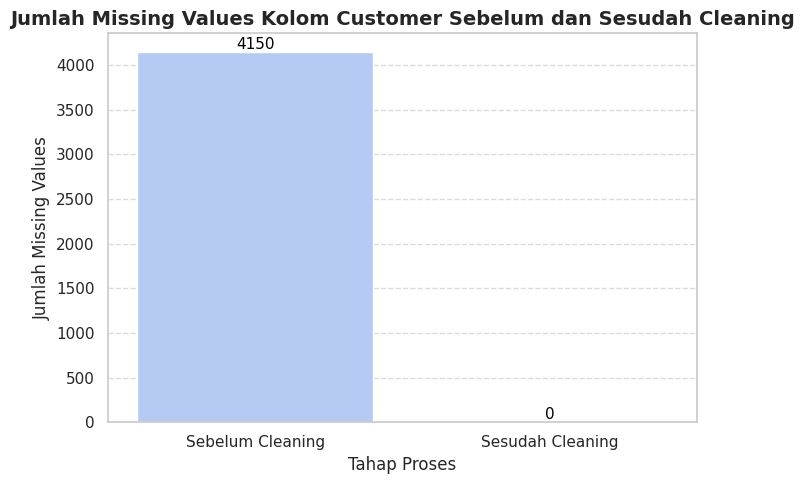

In [ ]:
# Get missing values count for 'Customer' before cleaning
missing_before = df['Customer'].isnull().sum()

# Get missing values count for 'Customer' after cleaning
# df_clean was created by dropping rows with missing Customer IDs
missing_after = df_clean['Customer'].isnull().sum()

# Create a DataFrame for plotting
missing_customer_data = pd.DataFrame({
    'Stage': ['Sebelum Cleaning', 'Sesudah Cleaning'],
    'Missing Values': [missing_before, missing_after]
})

# Create the bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x='Stage', y='Missing Values', data=missing_customer_data, palette='coolwarm')
plt.title('Jumlah Missing Values Kolom Customer Sebelum dan Sesudah Cleaning', fontsize=14, fontweight='bold')
plt.xlabel('Tahap Proses', fontsize=12)
plt.ylabel('Jumlah Missing Values', fontsize=12)

# Add data labels on top of the bars
for index, row in missing_customer_data.iterrows():
    plt.text(index, row['Missing Values'], f'{int(row['Missing Values'])}', color='black', ha="center", va='bottom', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

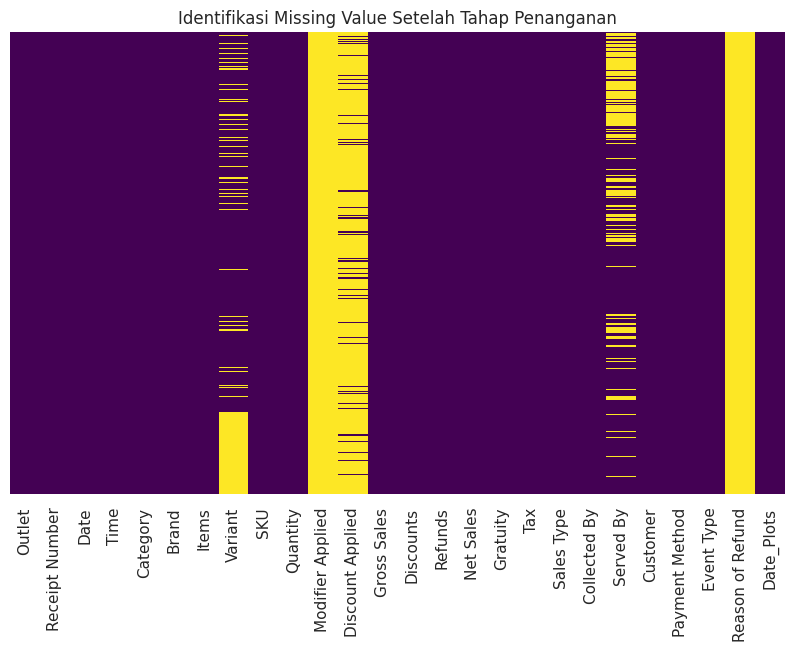

In [ ]:
# Visualisasi missing value dengan heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Identifikasi Missing Value Setelah Tahap Penanganan')
plt.show()

In [ ]:
columns_to_check = ['Variant', 'Modifier Applied', 'Discount Applied', 'Served By', 'Reason of Refund']

# Create a copy to avoid modifying the original DataFrame
df_temp_drop = df.copy()

# Drop rows where any of the specified columns have missing values
df_temp_drop = df_temp_drop.dropna(subset=columns_to_check)

total_data_after_drop = len(df_temp_drop)

print(f"Jumlah total data setelah menghapus baris dengan nilai kosong di kolom {', '.join(columns_to_check)} adalah: {total_data_after_drop} baris")

Jumlah total data setelah menghapus baris dengan nilai kosong di kolom Variant, Modifier Applied, Discount Applied, Served By, Reason of Refund adalah: 0 baris


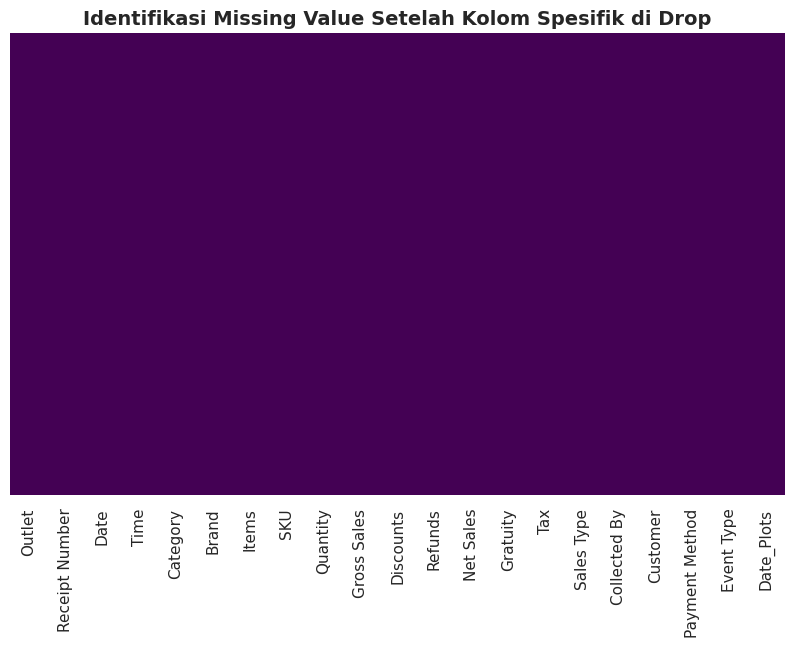

In [ ]:
# Tentukan kolom-kolom yang ingin di-drop
columns_to_drop = ['Variant', 'Modifier Applied', 'Discount Applied', 'Served By', 'Reason of Refund']

# Buat salinan df_clean untuk menghindari modifikasi df_clean asli
df_after_col_drop = df_clean.drop(columns=columns_to_drop, errors='ignore')

# Visualisasi missing value dengan heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_after_col_drop.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Identifikasi Missing Value Setelah Kolom Spesifik di Drop', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
rfm.head(10)

,Customer,Recency,Frequency,Monetary,Cluster,Nama_Segmen,PC1,PC2,Nama Segmen
0,'+628111038056,72,2,"252,600.00",2,Pelanggan Potensial (Promising),0.92,-0.31,Pelanggan Potensial
1,'+628111220288,190,1,"124,875.00",1,Pelanggan Berisiko (At Risk/Lost),-0.74,0.14,Pelanggan Berisiko
2,'+628112199413,55,2,"119,000.00",2,Pelanggan Potensial (Promising),0.51,-0.86,Pelanggan Potensial
3,'+62811251842,217,2,"337,500.00",1,Pelanggan Berisiko (At Risk/Lost),0.34,1.12,Pelanggan Berisiko
4,'+628112578880,188,1,"182,300.00",1,Pelanggan Berisiko (At Risk/Lost),-0.48,0.32,Pelanggan Berisiko
5,'+628112642011,30,6,"980,350.00",0,Pelanggan Setia (Loyal/Champion),3.21,0.49,Pelanggan Setia
6,'+628112652557,201,2,"464,670.00",2,Pelanggan Potensial (Promising),0.63,1.15,Pelanggan Potensial
7,'+628112663355,289,1,"49,900.00",1,Pelanggan Berisiko (At Risk/Lost),-1.87,0.53,Pelanggan Berisiko
8,'+62811267690,145,2,"235,800.00",2,Pelanggan Potensial (Promising),0.48,0.30,Pelanggan Potensial
9,'+628112950303,30,1,"187,000.00",2,Pelanggan Potensial (Promising),0.38,-1.06,Pelanggan Potensial
